# **Week 11: Inference for Small Samples (Solutions)**

```
.------------------------------------.
|   __  ____  ______  _  ___ _____   |
|  |  \/  \ \/ / __ )/ |/ _ \___  |  |
|  | |\/| |\  /|  _ \| | | | | / /   |
|  | |  | |/  \| |_) | | |_| |/ /    |
|  |_|  |_/_/\_\____/|_|\___//_/     |
'------------------------------------'

```

Through the following examples, we will explore the concepts of (small-sample) hypothesis testing (SSHT), and confidence intervals, and examine their practical implications.

**Why focus on small samples?**

- Less data means we cannot rely on the “law of large numbers” or asymptotic properties. Every conclusion depends heavily on the assumptions of our statistical model. For instance, if we assume data are normally distributed, that assumption has a bigger impact when the sample is small.

- In contrast, with large samples, many statistical methods rely on asymptotic properties, meaning they behave approximately correctly ***almost*** regardless of the underlying model. Essentially, large-sample inference is almost model-free.

## **Pre-Configurating the Notebook**

### **Switching to the R Kernel on Colab**

By default, Google Colab uses Python as its programming language. To use R instead, you’ll need to manually switch the kernel by going to **Runtime > Change runtime type**, and selecting R as the kernel. This allows you to run R code in the Colab environment.

However, our notebook is already configured to use R by default. Unless something goes wrong, you shouldn’t need to manually change runtime type.

### **Importing Required Packages**
**Run the following lines of code**:

In [1]:
#Do not modify

setwd("/content")

# Remove `MXB107-Notebooks` if exists,
if (dir.exists("MXB107-Notebooks")) {
  system("rm -rf MXB107-Notebooks")
}

# Fork the repository
system("git clone https://github.com/edelweiss611428/MXB107-Notebooks.git")

# Change working directory to "MXB107-Notebooks"
setwd("MXB107-Notebooks")

#
invisible(source("R/preConfigurated.R"))

Loading required package: ggplot2

Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: tidyr

Loading required package: stringr

Loading required package: magrittr


Attaching package: ‘magrittr’


The following object is masked from ‘package:tidyr’:

    extract


Loading required package: IRdisplay

Loading required package: png

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘png’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: grid

Loading required package: knitr



**Do not modify the following**

In [2]:
if (!require("testthat")) install.packages("testthat"); library("testthat")

test_that("Test if all packages have been loaded", {

  expect_true(all(c("ggplot2", "tidyr", "dplyr", "stringr", "magrittr", "knitr") %in% loadedNamespaces()))

})

Loading required package: testthat


Attaching package: ‘testthat’


The following objects are masked from ‘package:magrittr’:

    equals, is_less_than, not




Test passed with 1 success 🥇.


## **Performing `t.test` in R**

R provides a built-in function `t.test()` to perform hypothesis testing on means using the Student’s t-distribution. It can handle:

- One-sample t-tests
- Two-sample t-tests (equal or unequal variance)
- Paired-sample t-tests

It also handles small-sample confidence intervals on means (Gaussianity assumed).




### **Vector Interface `t.test` - Default Usage**

**Usage:**

```r
t.test(x, y = NULL,
       alternative = c("two.sided", "less", "greater"),
       mu = 0,
       paired = FALSE,
       var.equal = FALSE,
       conf.level = 0.95)
```

**Arguments:**

- `x`: numeric vector of data (one-sample or first sample)
- `y`: numeric vector of second sample (for two-sample tests)
- `mu`: Hypothesised mean for one-sample tests, or hypothesised difference for paired/two-sample tests
- `alternative`: `"two.sided"` (default), `"less"`, `"greater"`
- `paired`: TRUE for paired-sample test, FALSE for independent samples
- `var.equal`: TRUE for pooled-variance two-sample test, FALSE for Welch’s test
- `conf.level`: confidence level for interval (default 0.95)

#### **Reference Table**
| Scenario              | x             | y             | paired | var.equal | mu / difference under H0 |
|------------------------|---------------|---------------|--------|-----------|--------------------------|
| One-sample             | data          | -             | FALSE  | -         | hypothesised mean        |
| Two-sample Pooled      | sample1       | sample2       | FALSE  | TRUE      | hypothesised difference  |
| Two-sample Welch's       | sample1       | sample2       | FALSE  | FALSE     | hypothesised difference  |
| Paired-sample          | before        | after         | TRUE   | -         | hypothesised mean difference   |



### **Formula Interface**

The `t.test` function also provides a **formula interface**, which is often more convenient when working with `data.frame`s.  

- It is still the **same function** as the vector interface, but behaves differently depending on the input type.  
- Internally, `t.test` is an **S3 generic** in R, meaning it has different methods depending on whether you pass a numeric vector or a formula.  
- This is why we saw the **vector interface** earlier, and now we have the **formula interface**.

**Usage:**

```r
t.test(formula, data,
       subset,
       na.action,
       alternative = c("two.sided", "less", "greater"),
       mu = 0,
       paired = FALSE,
       var.equal = FALSE,
       conf.level = 0.95)
```

**Arguments:**

- `formula`: A formula describing the model, e.g. `response ~ group` for two-sample tests, or `response` for one-sample tests  
- `data`: The data frame containing the variables in the formula  
- `subset`: Optional logical vector to select a subset of the data  
- `na.action`: How to handle missing values (`na.omit` by default)  
- `alternative`: `"two.sided"` (default), `"less"`, or `"greater"`  
- `mu`: Hypothesised mean for one-sample tests, or hypothesised difference for paired/two-sample tests  
- `paired`: `TRUE` for paired-sample test, `FALSE` for independent samples  
- `var.equal`: `TRUE` for pooled-variance two-sample test, `FALSE` for Welch’s test  
- `conf.level`: Confidence level for the interval (default 0.95)

A **`formula`** specifies which column contains the response variable (numeric values) and which column contains the grouping variable (factor).  
  - Typical form: `response ~ group`  
  - For a one-sample test, you can just use `response` (no grouping variable needed).  
- Data should ideally be in **long format**, where one column specifies the measured values, and another column specifies the group/label. This is especially useful for multiple groups.


#### **Reference Table**

| Scenario              | Formula                         | paired | var.equal | mu / difference under H0 |
|-----------------------|---------------------------------|--------|-----------|--------------------------|
| One-sample            | response ~ 1                     | FALSE  | -         | hypothesised mean        |
| Two-sample Pooled     | response ~ group, var.equal=TRUE | FALSE  | TRUE      | hypothesised difference  |
| Two-sample Welch's    | response ~ group                 | FALSE  | FALSE     | hypothesised difference  |
| Paired-sample         | (response_after - response_before) ~ 1 | TRUE   | -         | hypothesised mean difference |





### **Examples**

The `sleep` dataset contains extra hours of sleep gained by 20 patients under two different drugs.

Through out this section, we assume a 95% significance level.

In [3]:
sleep %>% str()

'data.frame':	20 obs. of  3 variables:
 $ extra: num  0.7 -1.6 -0.2 -1.2 -0.1 3.4 3.7 0.8 0 2 ...
 $ group: Factor w/ 2 levels "1","2": 1 1 1 1 1 1 1 1 1 1 ...
 $ ID   : Factor w/ 10 levels "1","2","3","4",..: 1 2 3 4 5 6 7 8 9 10 ...


#### **Example 1: One-Sample t-test**

Is there any evidence that the average extra sleep (in hours) of the first group is different from 1?



We want to test whether there is any evidence that the average extra sleep (in hours) of the first group (denonted $\mu$) is different from 1. Formally, the hypotheses are:
$$
\begin{align}
H_0: \mu &= 1 \\
H_1: \mu &\neq 1
\end{align}
$$

Since the sample size is small, a $t$-test might be appropriate here.

In [5]:
# let's pull out the extra sleep data for group 1
extra_group1 = sleep$extra[sleep$group == "1"]
extra_group1
length(extra_group1)



[1]  0.7 -1.6 -0.2 -1.2 -0.1  3.4  3.7  0.8  0.0  2.0

[1] 10

The following code conducts the t-test for this data.

In [7]:
t.test(extra_group1, mu = 1, alternative = "two.sided")


	One Sample t-test

data:  extra_group1
t = -0.4419, df = 9, p-value = 0.669
alternative hypothesis: true mean is not equal to 1
95 percent confidence interval:
 -0.5297804  2.0297804
sample estimates:
mean of x 
     0.75 


In [ ]:
t.test(extra~1, data = group1, mu = 1, alternative = "two.sided")


	One Sample t-test

data:  extra
t = -0.4419, df = 9, p-value = 0.669
alternative hypothesis: true mean is not equal to 1
95 percent confidence interval:
 -0.5297804  2.0297804
sample estimates:
mean of x 
     0.75 


##### **What Does the Summary from `t.test` Tell Us?**

`t.test()` by default generates a **statistical summary**, which includes:

- $t$-statistic: the value of the test statistic for the t-test  
- Degrees of freedom (df): for the $t$-distribution under the null hypothesis  
- p-value: the probability of observing a value as extreme (or more extreme) than the observed test statistic, assuming the null hypothesis is true  

- Confidence interval (CI): a plausible range for population mean (by default, a symmetric CI at 95% confidence level).
  - If the hypothesised value under `H0` lies **outside** this interval, it corresponds to rejecting `H0` at the same significance level. **This is a nice connection between confidence interval and hypothesis testing**.






Here we can see that the p-value is around 0.67, which is quite large.  Thus there is insufficient evidence against the null.  Hence, there is no evidence to suggest that the extra sleep time for group 1 is difference to 1 hour.

Let's see if we can get the same result doing the calculations "by hand" (using R as a calculator, and also for the quantile function of the t-distribution).

In [9]:

# compute the test statistic
t = (mean(extra_group1) - 1)/(sd(extra_group1)/sqrt(length(extra_group1)))
t

# now compute the p-value for two-sided hypotheses
p = 2*pt(t,length(extra_group1) - 1)
p

# we see we get the exact same result as using the in-built function


[1] -0.4419034

[1] 0.6689866

#### **Example 2: Two-Sample t-test**

Is there a difference in the mean extra sleep hours between patients taking Drug `"1"` and Drug `"2"`?


Note that the `sleep` dataset is already in the long format, where `extra` is the response variable and `group` shows the labels.

In [ ]:
sleep %>% kable()



| extra|group |ID |
|-----:|:-----|:--|
|   0.7|1     |1  |
|  -1.6|1     |2  |
|  -0.2|1     |3  |
|  -1.2|1     |4  |
|  -0.1|1     |5  |
|   3.4|1     |6  |
|   3.7|1     |7  |
|   0.8|1     |8  |
|   0.0|1     |9  |
|   2.0|1     |10 |
|   1.9|2     |1  |
|   0.8|2     |2  |
|   1.1|2     |3  |
|   0.1|2     |4  |
|  -0.1|2     |5  |
|   4.4|2     |6  |
|   5.5|2     |7  |
|   1.6|2     |8  |
|   4.6|2     |9  |
|   3.4|2     |10 |

Let $x_1, \dots, x_{n_1}$ and $y_1, \dots, y_{n_2}$  be the extra sleep hours gained by patients in the groups `"1"` and `"2"` in the `sleep` dataset. We assume that

$$
x_1, \dots, x_{n_1} \sim \text{i.i.d. } \mathcal{N}(\mu_1, \sigma_1^2)
$$

$$
y_1, \dots, y_{n_2} \sim \text{i.i.d. } \mathcal{N}(\mu_2, \sigma_2^2)
$$


We want to test whether there is any evidence that the average extra sleep hours of the two groups are diffent. Formally, the hypotheses are:
$$
\begin{align}
H_0: \mu_1 - \mu_2 &= 0 \\
H_1: \mu_1 - \mu_2 &\neq 0
\end{align}
$$

This is **not a paired sample**, since patients are allocated into two separate groups, and no patient takes both drugs.  It is also reasonable to assume that these two populations are **independent**, at least in this example, where we assume the study is well-signed, but this assumption may not always hold in practice.  

*A quick detour from what we are doing…* Various factors can compromise independence, for example:  

- If patients know which drug they are taking, their behavior or reporting may be affected (placebo effect, expectations, or bias).  
- If there is some systematic way in which patients are assigned to groups, the two samples may not be truly independent.  

Always think critically about whether the **independence assumption** is valid for your study.


***Back to the question***, given the sample sizes, we can use a two-sample t-test. Which one to use? Let's take a look at box plots of `extra` for the two groups.

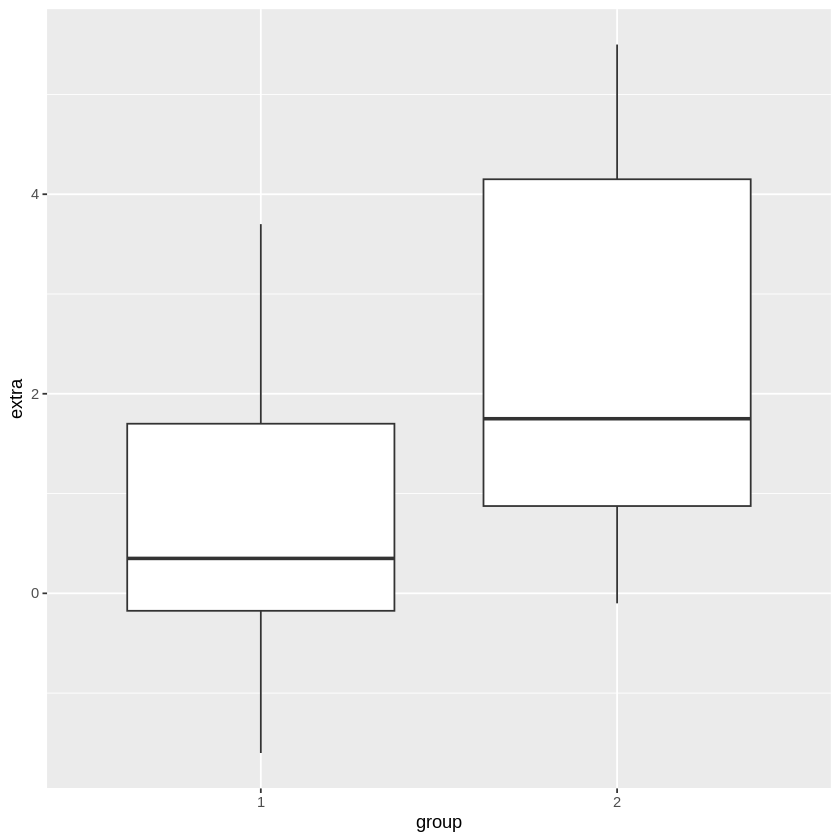

In [ ]:
sleep %>%
  ggplot(aes(x = group, y = extra)) +
  geom_boxplot()

Group 2 seems to have a higher average of extra hours of sleep, and the IQR appears to be roughly double that of group 1. There do not seem to be any outliers in either group.  The median in group 2 appears to be slightly shifted towards the 25% quantile, which could suggest non-Gaussianity.

However, these might also be due to random variation, especially since the sample size for each group is quite small. We can also check the **rule of thumb** discussed earlier to decide whether to use the pooled-variance t-test or Welch's test.


In [ ]:
sleep %>%
  group_by(group) %>%
  summarise(smpl_var = var(extra)) -> group_vars

group_vars

group_vars %>% pull(smpl_var) %>% max / group_vars %>% pull(smpl_var) %>% min

group,smpl_var
<fct>,<dbl>
1,3.200556
2,4.009000


[1] 1.252595

As

$$
\frac{\text{larger } s^2}{\text{smaller } s^2} = \frac{4.009000}{3.200556} \approx 1.25 < 3,
$$  

We can use the pooled-variance t-test in this example. The following code cells give the same outputs.

In [ ]:
t.test(x = sleep %>% filter(group == "1") %>% pull(extra),
       y = sleep %>% filter(group == "2") %>% pull(extra),
       mu = 0, alternative = "two.sided", var.equal = TRUE)


	Two Sample t-test

data:  sleep %>% filter(group == "1") %>% pull(extra) and sleep %>% filter(group == "2") %>% pull(extra)
t = -1.8608, df = 18, p-value = 0.07919
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -3.363874  0.203874
sample estimates:
mean of x mean of y 
     0.75      2.33 


Here, the p-value suggests there is no evidence to reject $H_0$ at the $\alpha = 0.05$ significance level. We can also compare the absolute value of test statistic (two-sided test) to  the 97.5th percentile of the Student’s t-distribution with 18 degrees of freedom (10 + 10 - 2).

In [ ]:
t.test(extra ~ group, data = sleep, mu = 0, alternative = "two.sided", var.equal = TRUE) -> output
abs(output$statistic) > qt(0.975, df = 18)
# Do not reject the null hypothesis

t 
FALSE

### **Exercise**

Is there a difference in the mean extra sleep hours between patients taking Drug "1" and Drug "2"?  

Perform a **Welch’s t-test** to test this hypothesis using `t.test` function and compare the results to the previous two-sample t-test obtained using the pooled variance.


In [ ]:
t.test(extra ~ group, data = sleep, mu = 0, alternative = "two.sided", var.equal = FALSE) -> output
output
abs(output$statistic) > qt(0.975, df = output$parameter)
# Do not reject the null hypothesis


	Welch Two Sample t-test

data:  extra by group
t = -1.8608, df = 17.776, p-value = 0.07939
alternative hypothesis: true difference in means between group 1 and group 2 is not equal to 0
95 percent confidence interval:
 -3.3654832  0.2054832
sample estimates:
mean in group 1 mean in group 2 
           0.75            2.33 


t 
FALSE

## **The T Statistical Table**



This table shows the critical t-values for the Student’s t-distribution at various degrees of freedom (df) and significance levels ($\alpha$). Historically, such tables were used in textbooks and labs before computers to quickly determine whether a t-statistic was extreme enough to reject the null hypothesis.  

Mathematically, each value corresponds to a quantile of the cumulative distribution function (CDF) of the $t$-distribution. For example, the entry for df = 10 and $\alpha = 0.05$ is the 95th percentile of the t-distribution with 10 degrees of freedom, which is the critical value for a **one-sided right-tailed test at the 5% significance level**, or equivalently, for a **two-sided test at the 10% significance level**.

This allows you to compare your observed t-statistic directly to the table value to decide whether to reject the null hypothesis.

**VERY IMPORTANT:** Note that variations of t-statistic tables exist. Some show **two-sided critical values** ($1 - \alpha/2$ quantile), some show **one-sided critical values** ($1 - \alpha$ quantile), and some show both. Be careful when using these tables, know which convention is being used, and ask for clarification if it is unclear.

**Note**: This table only shows integer $\nu$. If a fractional number of degrees of freedom is encountered (as in Welch’s test), round it to the **nearest df**.



In [ ]:
generateTTable()



|      | alpha=0.2| alpha=0.1| alpha=0.05| alpha=0.025| alpha=0.01| alpha=0.005| alpha=0.001|
|:-----|---------:|---------:|----------:|-----------:|----------:|-----------:|-----------:|
|df=1  |    1.3764|    3.0777|     6.3138|     12.7062|    31.8205|     63.6567|    318.3088|
|df=2  |    1.0607|    1.8856|     2.9200|      4.3027|     6.9646|      9.9248|     22.3271|
|df=3  |    0.9785|    1.6377|     2.3534|      3.1824|     4.5407|      5.8409|     10.2145|
|df=4  |    0.9410|    1.5332|     2.1318|      2.7764|     3.7469|      4.6041|      7.1732|
|df=5  |    0.9195|    1.4759|     2.0150|      2.5706|     3.3649|      4.0321|      5.8934|
|df=6  |    0.9057|    1.4398|     1.9432|      2.4469|     3.1427|      3.7074|      5.2076|
|df=7  |    0.8960|    1.4149|     1.8946|      2.3646|     2.9980|      3.4995|      4.7853|
|df=8  |    0.8889|    1.3968|     1.8595|      2.3060|     2.8965|      3.3554|      4.5008|
|df=9  |    0.8834|    1.3830|     1.8331|      2.2622|   

## **Workshop Questions**




### **Question 1: Which t-test to Use?**

For each of the following scenarios, decide which type of t-test should be used (one-sample, two-sample pooled, Welch’s, or paired-sample) and explain your reasoning.

**Scenarios:**

1. Measure the heart rate of participants before and after swimming.

2. A factory claims that the average weight of cereal boxes is 500 grams. You collect a sample of boxes and measure their weights.

3. Compare math test scores between students taught with method A and students taught with method B.

4. Compare math test scores of students who take both specialist maths and regular maths.

5.  Measure the heart rate of participants after drinking Coffee 1. One week later, the same participants drink Coffee 2 and their heart rate is measured again. Compare the heart rates between the two types of coffee.




**Solutions:**

1. Paired-sample t-test can be used as the same participants are measured twice (before and after), so the measurements are dependent.

2. One-sample t-test can be used as you are comparing a sample mean to a known/hypothesised population mean, which is exactly what a one-sample t-test is designed for.

3. Two-sample pooled t-test (or Welch’s t-test if unequal variance is suspected) can be used as it is reasonable to assume independent populations here.

4. Paired-sample t-test can be used as the same students are measured in two subjects, making the data *dependent.

5. Paired-sample t-test can be used because the same participants are measured after two conditions, making the data dependent (e.g., both measurements depend on each participant's baseline heart rate).

### **Question 2**

A geologist collected twenty ore samples and randomly divided them into two separate groups. She then used two different techniques to measure the amount of titanium present in the samples. The data are:

In [ ]:
group1 = c(0.011,0.013,0.013,0.015,0.014,0.013,0.010,0.013,0.011,0.012)
group2 = c(0.008,0.018,0.015,0.017,0.017,0.012,0.012,0.015,0.016,0.016)

Perform hypothesis testing to evaluate whether these two methods of taking measurements are equivalent. Now multiply the measurements by 1000, do you expect your test results to be any different? Repeat the test and compare the results. Use $\alpha = 0.05$.

Let $x_1, \dots, x_{10}$ denote the measurements of titanium in ore samples using **instrument 1** (`group1`), and $y_1, \dots, y_{10}$ denote the measurements using **instrument 2** (`group2`). Assuming the measurements are independent and normally distributed:

$$
x_1, \dots, x_{10} \sim \text{i.i.d. } \mathcal{N}(\mu_1, \sigma_1^2)
$$
$$
y_1, \dots, y_{10} \sim \text{i.i.d. } \mathcal{N}(\mu_2, \sigma_2^2)
$$

Formally, the hypotheses are:

$$
H_0: \mu_1 - \mu_2 = 0 \\
H_1: \mu_1 - \mu_2 \neq 0
$$

It is reasonable to assume independent populations here. We can use a two-sample $t$-test (for example, with `var.equal = FALSE`). Why? Check the variance ratio :).

In [ ]:
group1 = c(0.011,0.013,0.013,0.015,0.014,0.013,0.010,0.013,0.011,0.012)
group2 = c(0.011,0.016,0.013,0.012,0.015,0.012,0.017,0.013,0.014,0.015)
# var.equal = FALSE
t.test(group1, group2)
t.test(group1 * 1000, group2 * 1000)


	Welch Two Sample t-test

data:  group1 and group2
t = -1.6767, df = 17.003, p-value = 0.1119
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -0.0029357463  0.0003357463
sample estimates:
mean of x mean of y 
   0.0125    0.0138 



	Welch Two Sample t-test

data:  group1 * 1000 and group2 * 1000
t = -1.6767, df = 17.003, p-value = 0.1119
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -2.9357463  0.3357463
sample estimates:
mean of x mean of y 
     12.5      13.8 


The null hypothesis $H_0: \mu_1 - \mu_2 = 0$ is not affected by multiplying both groups by a common constant. Moreover, the standard deviation is scaled by the same factor as the mean difference, the $t$-statistic remains unchanged, and the test produces the same result.

Since both CIs do contain 0, we do not reject the null hypothesis at 95% significance level.

### **Question 3: Oh no!!!**


Oh no!!! The geologist in **Question 2** realises she made a mistake: each element of the same rock was measured using two different instruments (`group1` and `group2`). Given this new information, perform hypothesis testing to evaluate whether these two methods of taking measurements are equivalent. Use $\alpha = 0.05$.

Let $x_1, \dots, x_{10}$ and $y_1, \dots, y_{10}$ be the measurements of the same rock taken by **instrument 1** (`group1`) and **instrument 2** (`group2`). Let $d_i = x_i - y_i$ be the difference for each pair. We assume

$$
d_1, \dots, d_{10} \sim \text{i.i.d. } \mathcal{N}(\mu_d, \sigma_d^2)
$$

Formally, the hypotheses are:

$$
H_0: \mu_d = 0 \\
H_1: \mu_d \neq 0
$$


We want to test whether there is any evidence that the average extra sleep hours of the two groups are diffent. Formally, the hypotheses are:

Since the two populations are **dependent and paired**, a paired-sample t-test is more appropriate. Here, the correlation between `group1` and `group2` is 0.577.

[1] 0.5769831


	One Sample t-test

data:  group1 - group2
t = -2.6411, df = 9, p-value = 0.02687
alternative hypothesis: true mean is not equal to 0
95 percent confidence interval:
 -0.0038986955 -0.0003013045
sample estimates:
mean of x 
  -0.0021 



	One Sample t-test

data:  1000 * group1 - 1000 * group2
t = -2.6411, df = 9, p-value = 0.02687
alternative hypothesis: true mean is not equal to 0
95 percent confidence interval:
 -3.8986955 -0.3013045
sample estimates:
mean of x 
     -2.1 


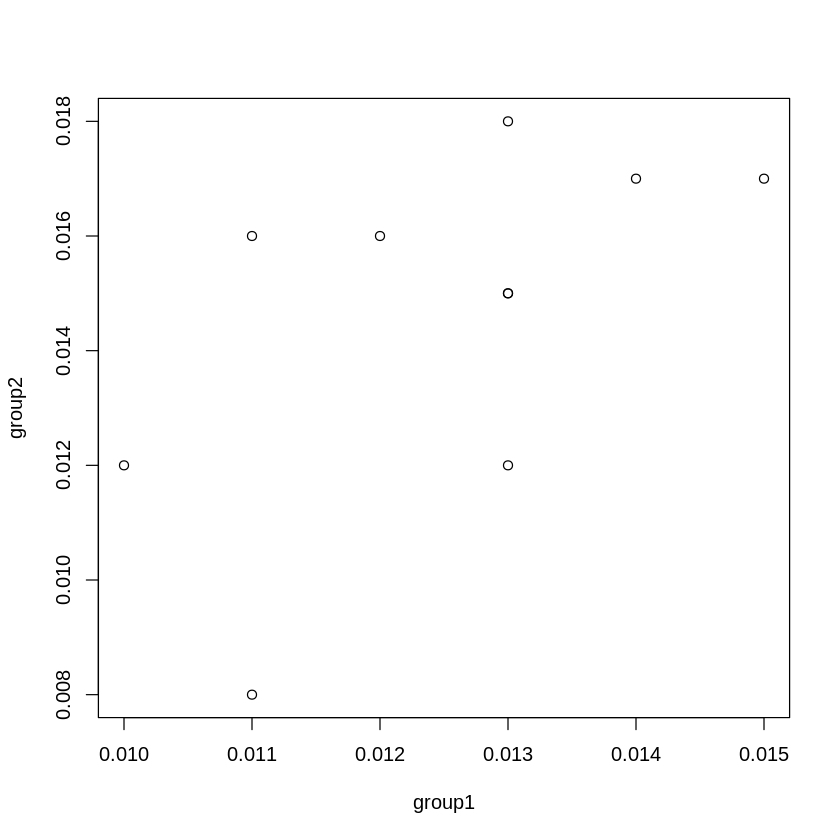

In [ ]:
group1 = c(0.011,0.013,0.013,0.015,0.014,0.013,0.010,0.013,0.011,0.012)
group2 = c(0.008,0.018,0.015,0.017,0.017,0.012,0.012,0.015,0.016,0.016)
cor(group1, group2)
plot(group1, group2)

t.test(group1-group2)
t.test(1000*group1-1000*group2)

The null hypothesis $H_0: \mu_d = 0$ is not affected by multiplying both groups by a common constant. Moreover, the standard deviation is scaled by the same factor as the mean difference, the $t$-statistic remains unchanged, and the test produces the same result.

Since both CIs do not contain 0, at 95% significance level, we reject the null hypothesis that the two instruments are equivalent, favouring the alternative one that they are different.


**Note**: Ignoring the dependence nature may give invalid inference.

### **Question 4**


Consider the data on weights (in grams) of packages of mince, is there any evidence that the average weight of a package of mince is less than 500g, assuming a Type 1 error of $0.01$?

Assuming the weights (in grams) of these packages, $x_1, ..., x_n \sim \text{i.i.d. } \mathcal{N}(\mu, \sigma^2)$, the hypotheses are:

$$
H_0: \mu = 500 \\
H_1: \mu < 500
$$

In [ ]:
smpl_data = c(490.32, 449.46, 440.38, 535.72, 640.14, 581.12, 376.82, 481.24, 517.56, 626.52, 340.50, 435.84,490.32, 394.98, 404.06, 404.06, 435.84, 508.48, 508.48, 422.22, 562.96, 404.06, 517.56, 417.68, 535.72, 531.18)
t.test(smpl_data, mu = 500, alternative = "less")


	One Sample t-test

data:  smpl_data
t = -1.4035, df = 25, p-value = 0.08639
alternative hypothesis: true mean is less than 500
95 percent confidence interval:
    -Inf 504.565
sample estimates:
mean of x 
   478.97 


Since the CI does contain 500, at 99% significance level, we do not reject the null hypothesis.

### **Question 5**

The classical $t$-test assumes that the data are normally distributed. In practice, this assumption often does not hold, which can substantially affect the Type I error rate (the probability of incorrectly rejecting a true null hypothesis).

Suppose we generate 10 independent observations from an exponential distribution with rate parameter $\lambda = \frac{1}{2}$. The expected value of this exponential random variable is $\frac{1}{\lambda} = 2$.

We want to test:

$$
\begin{align}
H_0: \mu &= 2 \text{ (the true mean)}\\
H_1: \mu &\neq 2 \\
\end{align}
$$

At a 95% significance level, if the $t$-test worked perfectly, we would expect the Type I error rate to be exactly 0.05.

#### **Question 5.1**

At a 95% significance level, repeat this process many times (e.g., 10,000 repetitions) to estimate the empirical Type I error rate.

In [ ]:
set.seed(123)
test_results = character(10^4)
for(i in 1:(10^4)){
  smpl_data = rexp(10, rate = 1/2)
  conf.int = t.test(smpl_data, mu = 2)$conf.int
  test_results[i] = ifelse(conf.int[1] < 2 & 2 < conf.int[2], "not rejected", "rejected")
}

prop.table(table(test_results))

test_results
not rejected     rejected 
      0.9003       0.0997 

The estimated Type I error is approximately 0.1, twice as large as 0.05.

#### **Question 5.2**

Repeat the simulation from **Question 5.1**, but now generate 10 observations from a Poisson distribution with $\lambda = 20$ and estimate the Type I error of the one-sample $t$-test at the 95% significance level. Compare the estimated Type I error to the one obtained before and explain the difference.

**Hint**: Examine the histograms of large samples from these two distributions to see their approximate shapes.

We want to test:

$$
\begin{align}
H_0: \mu &= 20 \text{ (the true mean)}\\
H_1: \mu &\neq 20 \\
\end{align}
$$

In [ ]:
set.seed(111)
test_results = character(10^4)
for(i in 1:(10^4)){
  smpl_data = rpois(10, 20)
  conf.int = t.test(smpl_data, mu = 20)$conf.int
  test_results[i] = ifelse(conf.int[1] < 20 & 20 < conf.int[2], "not rejected", "rejected")
}

prop.table(table(test_results))

test_results
not rejected     rejected 
      0.9489       0.0511 

The estimated Type I error is approximately 0.0511, quite close to 0.05.

**Why?**

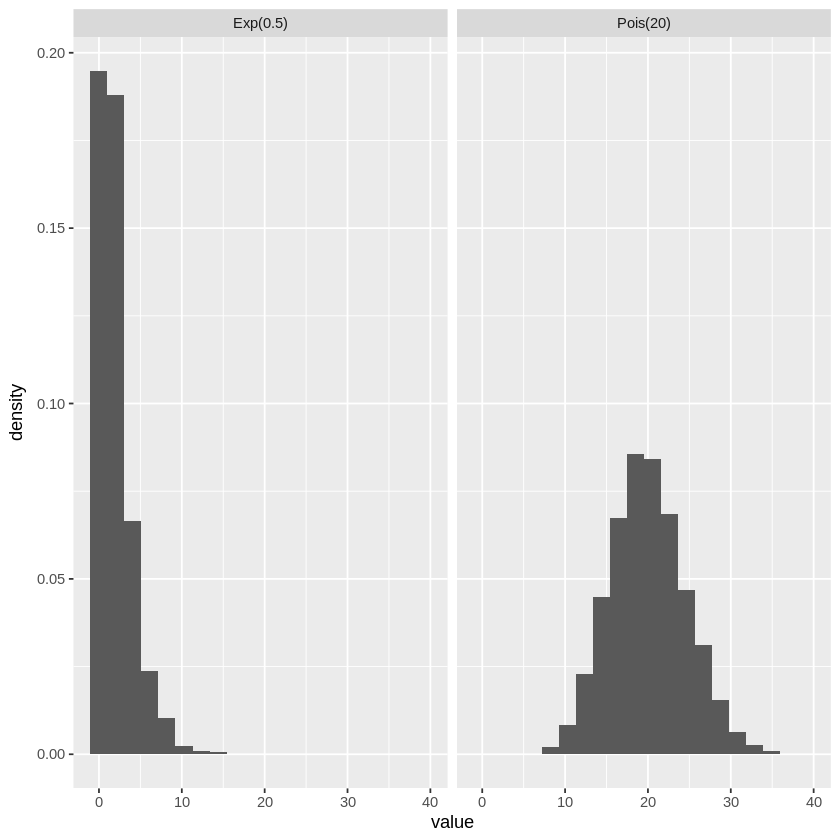

In [ ]:
set.seed(123)

df = data.frame(value = c(rexp(1e4, 0.5), rpois(1e4, 20)),
                distribution = rep(c("Exp(0.5)", "Pois(20)"), each = 1e4))

df %>%
  ggplot(aes(x = value)) +
  geom_histogram(aes(y = after_stat(density)), bins = 20) +
  facet_wrap(~distribution)

Exp(0.5) is heavily positive-skewed, while Pois(20) is quite *symmetric* and resembles the bell-shape curve of a Gaussian distribution.
